# 2 - Interval Analysis

## Imports

In [101]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [103]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import intervalanalysis_utils as ia

## Load + Preprocess Data

In [104]:
metadata = g.load_metadata()
metadata = metadata[metadata['recording_year'] >= 1950]

In [106]:
bins = np.arange(1950, 2030, 10) 
bin_labels = [f"{start}-{start+10}" for start in bins[:-1]]

subset_year = metadata[metadata['recording_year'].notna()].copy()
subset_year['year_bin'] = pd.cut(subset_year['recording_year'], bins=bins, labels=bin_labels, right=False)

## In-Label Intervals By year

In [109]:
ILC_year = g.load_labels(subset_year)
ILC_year['interval'] = ILC_year['label'].apply(lambda x: ia.label_to_intervals_semitones(x)[0])
ILC_year['interval from root'] = ILC_year['label'].apply(lambda x: ia.label_to_intervals_semitones_from_root(x)[0])
identifier = ['year_bin']
ILC_year_grouped = ILC_year.groupby(identifier, as_index=False).agg(list)
data_ILC_year = ia.create_data(ILC_year_grouped, identifier)


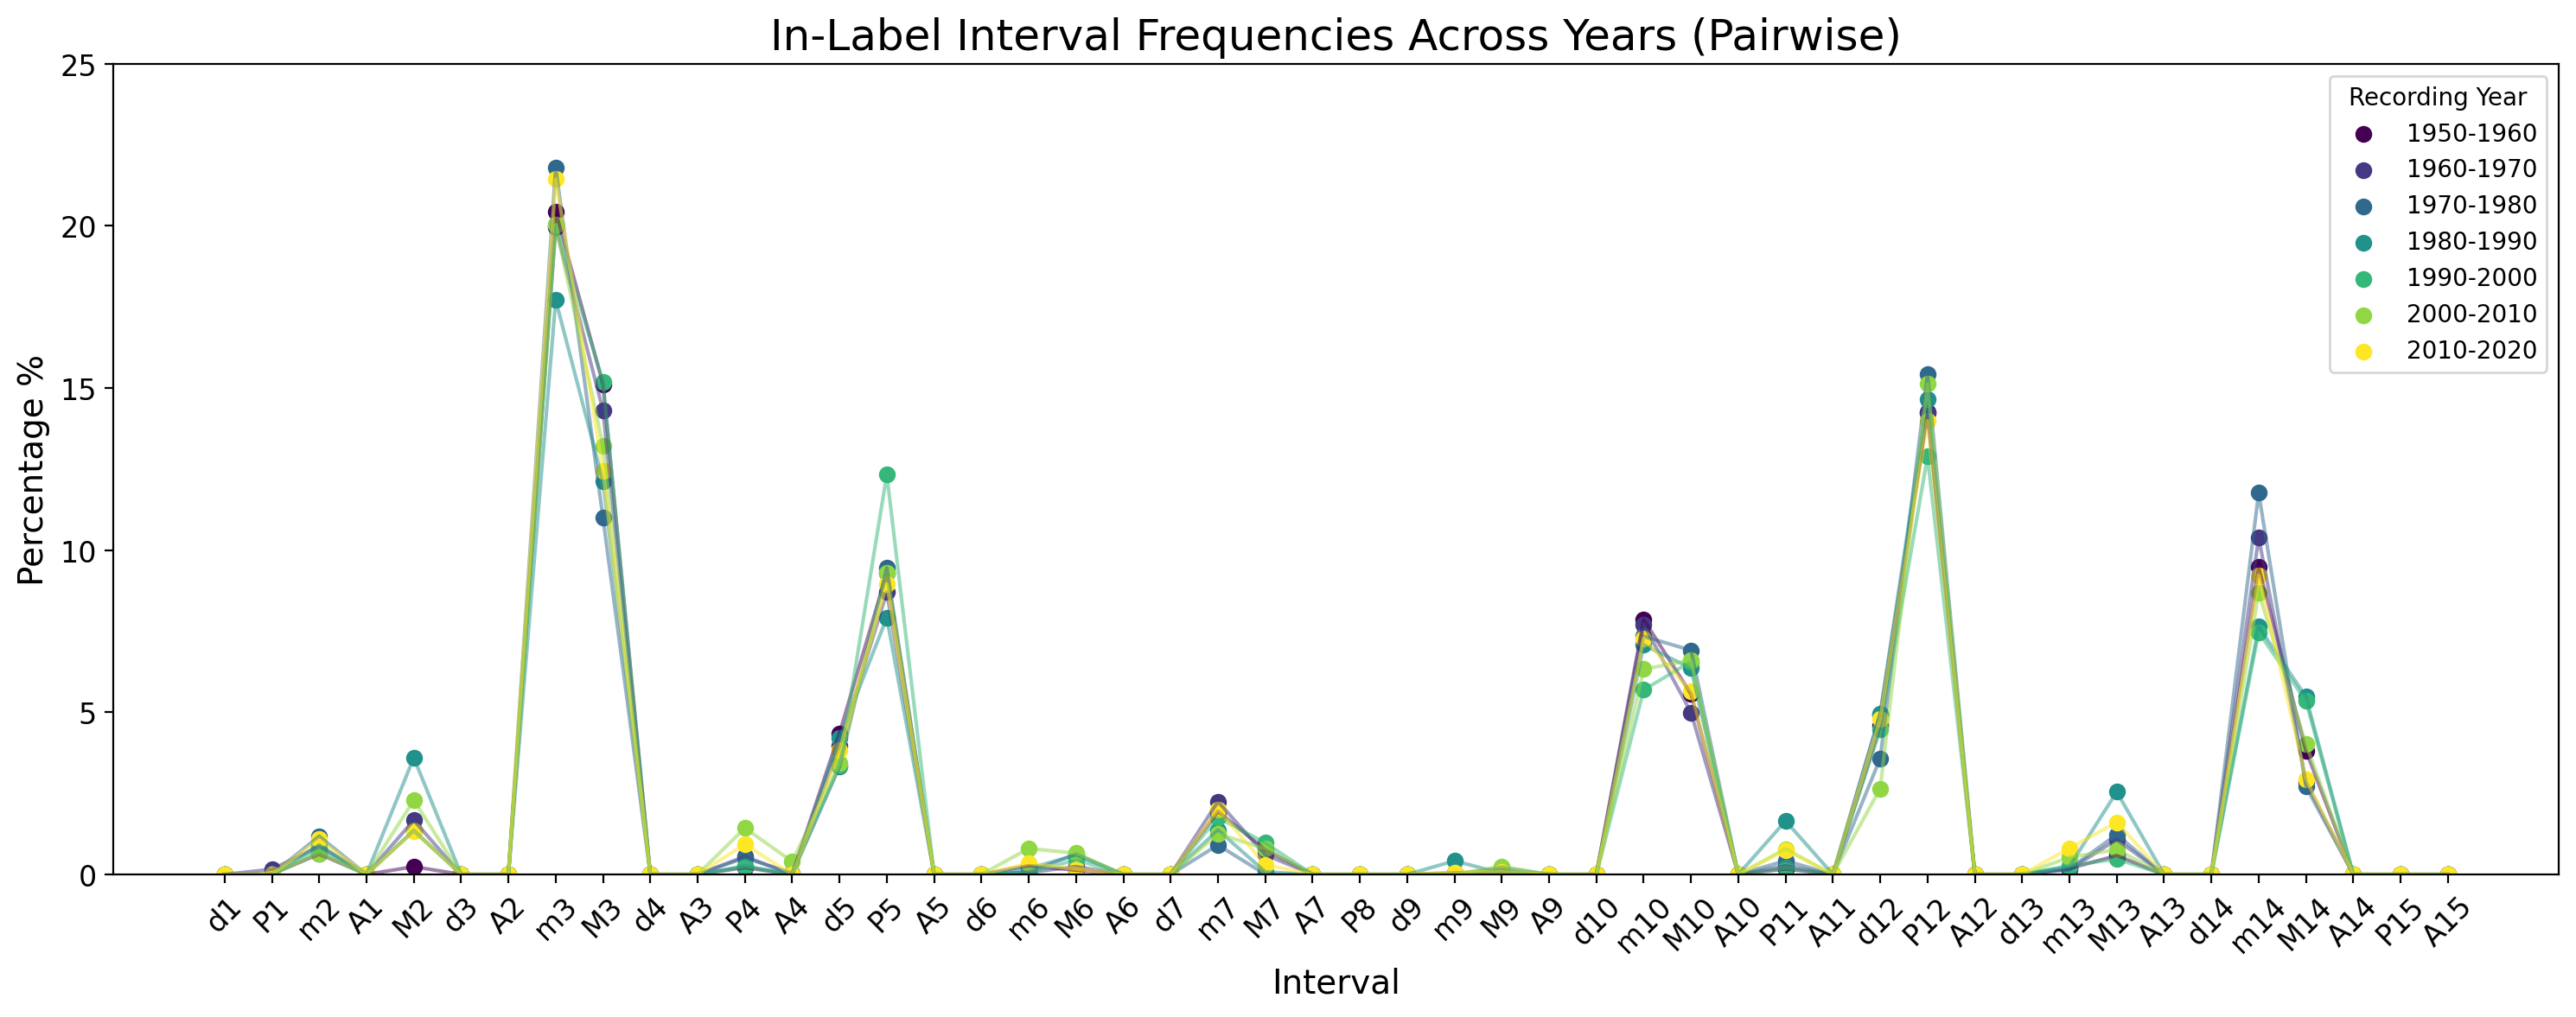

In [110]:
baseline_df = pd.DataFrame({
    'interval_name': ia.canonical_intervals,
    'percentage': 0.0
})

keys = list(data_ILC_year.keys())

fig, ax = plt.subplots(figsize=(15, 6))  # One figure and one axis

colors = plt.colormaps['viridis']

for i, key in enumerate(keys):

    interval = data_ILC_year[key]
    interval = pd.DataFrame({'interval_name': interval['interval'], 'duration': interval['duration_qb']})
    interval = interval.explode('interval_name')

    interval_counts = (
        interval.groupby(['interval_name'])['duration']
        .sum()
        .reset_index(name='weighted_count')
    )

    #interval_counts['semitone'] = interval_counts['interval_name'].apply(lambda x: m21.interval.Interval(x).semitones)
    interval_counts['semitone'] = interval_counts['interval_name'].map(ia.interval_order)
    count = interval_counts.sort_values('semitone', ascending=True)
    total = count['weighted_count'].sum()
    
    #Normalize
    count['percentage'] = (count['weighted_count'] / total)*100

    merged_df = pd.merge(
        baseline_df[['interval_name']],
        count[['interval_name', 'percentage']],
        on='interval_name',
        how='left'
    )

    # Fill NaNs with 0 where artist didn't have that interval
    merged_df['percentage'] = merged_df['percentage'].fillna(0)
    
    merged_df = merged_df[['interval_name', 'percentage']]
    
    # Plot bar chart
    ax.plot(merged_df['interval_name'], merged_df['percentage'], color=colors(i / (len(keys) - 1)), alpha=0.5)
    ax.scatter(merged_df['interval_name'], merged_df['percentage'], label=label, color=colors(i / (len(keys) - 1)))

ax.tick_params(axis='x', labelsize=12, rotation=45)
ax.tick_params(axis='y', labelsize=12)
ax.set_xlabel('Interval', fontsize=14)
ax.set_ylabel('Percentage %', fontsize=14)
ax.set_title(f'In-Label Interval Frequencies Across Years (Pairwise)', fontsize=18)
ax.legend(title='Recording Year')
ax.set_ylim(0, 25)

plt.tight_layout()
plt.savefig(f"../Results/Year_Interval_InLabel")
plt.show()

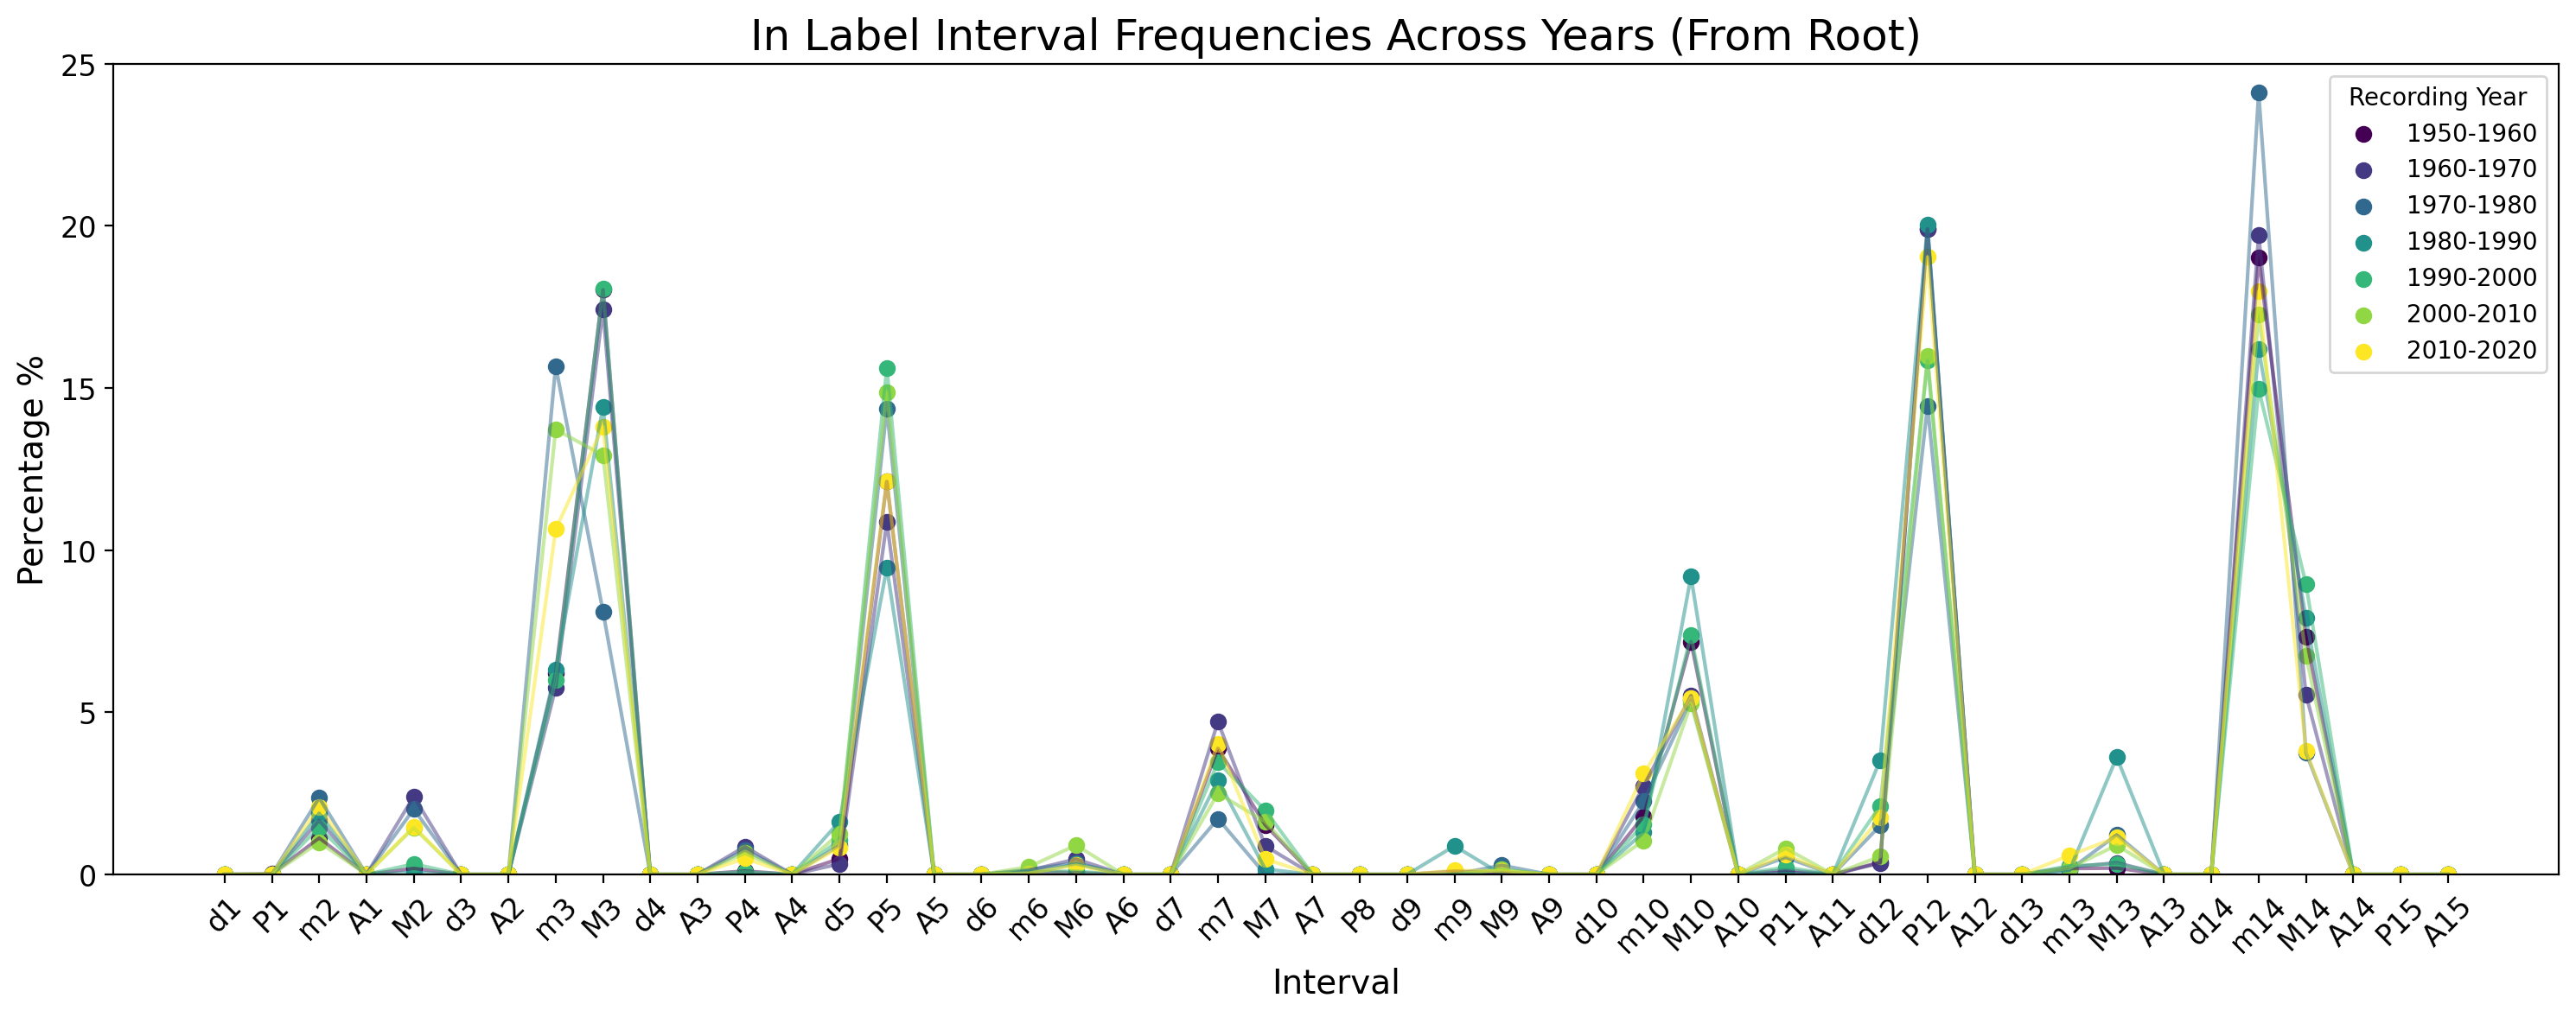

In [111]:
baseline_df = pd.DataFrame({
    'interval_name': ia.canonical_intervals,
    'percentage': 0.0
})

keys = list(data_ILC_year.keys())

fig, ax = plt.subplots(figsize=(15, 6))  # One figure and one axis

colors = plt.colormaps['viridis']

for i, key in enumerate(keys):
    
    interval = data_ILC_year[key]
    interval = pd.DataFrame({'interval_name': interval['interval from root'], 'duration': interval['duration_qb']})
    interval = interval.explode('interval_name')

    interval_counts = (
        interval.groupby(['interval_name'])['duration']
        .sum()
        .reset_index(name='weighted_count')
    )

    #interval_counts['semitone'] = interval_counts['interval_name'].apply(lambda x: m21.interval.Interval(x).semitones)
    interval_counts['semitone'] = interval_counts['interval_name'].map(ia.interval_order)
    count = interval_counts.sort_values('semitone', ascending=True)
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    merged_df = pd.merge(
        baseline_df[['interval_name']],
        count[['interval_name', 'percentage']],
        on='interval_name',
        how='left'
    )
    
    # Fill NaNs with 0 where artist didn't have that interval
    merged_df['percentage'] = merged_df['percentage'].fillna(0)
    
    merged_df = merged_df[['interval_name', 'percentage']]
    
    # Plot bar chart
    ax.plot(merged_df['interval_name'], merged_df['percentage'], color=colors(i / (len(keys) - 1)), alpha=0.5)
    ax.scatter(merged_df['interval_name'], merged_df['percentage'], label=label, color=colors(i / (len(keys) - 1)))

ax.set_ylim(0, 25) 
ax.tick_params(axis='x', labelsize=12, rotation=45)
ax.tick_params(axis='y', labelsize=12)
ax.set_xlabel('Interval', fontsize=14)
ax.set_ylabel('Percentage %', fontsize=14)
ax.set_title(f'In Label Interval Frequencies Across Years (From Root)', fontsize=18)
ax.legend(title='Recording Year')

plt.tight_layout()
plt.savefig(f"../Results/Year_Interval_InLabel_From_Root")
plt.show()

## Heard Interval Analysis By Year

In [116]:
heard_harmonies = heard_harmonies[heard_harmonies['recording_year'].notna()]
heard_harmonies['year_bin'] = pd.cut(heard_harmonies['recording_year'], bins=bins, labels=bin_labels, right=False)
heard_harmonies = heard_harmonies[(heard_harmonies['year_bin'] != '1930-1940')& (heard_harmonies['year_bin'] != '1940-1950')]
heard_harmonies['year_bin'] = heard_harmonies['year_bin'].cat.remove_unused_categories()
identifier = ['year_bin']
heard_harmonies_grouped = heard_harmonies.groupby(identifier, as_index=False).agg(list)
data_heard_year = ia.create_data(heard_harmonies_grouped, identifier)

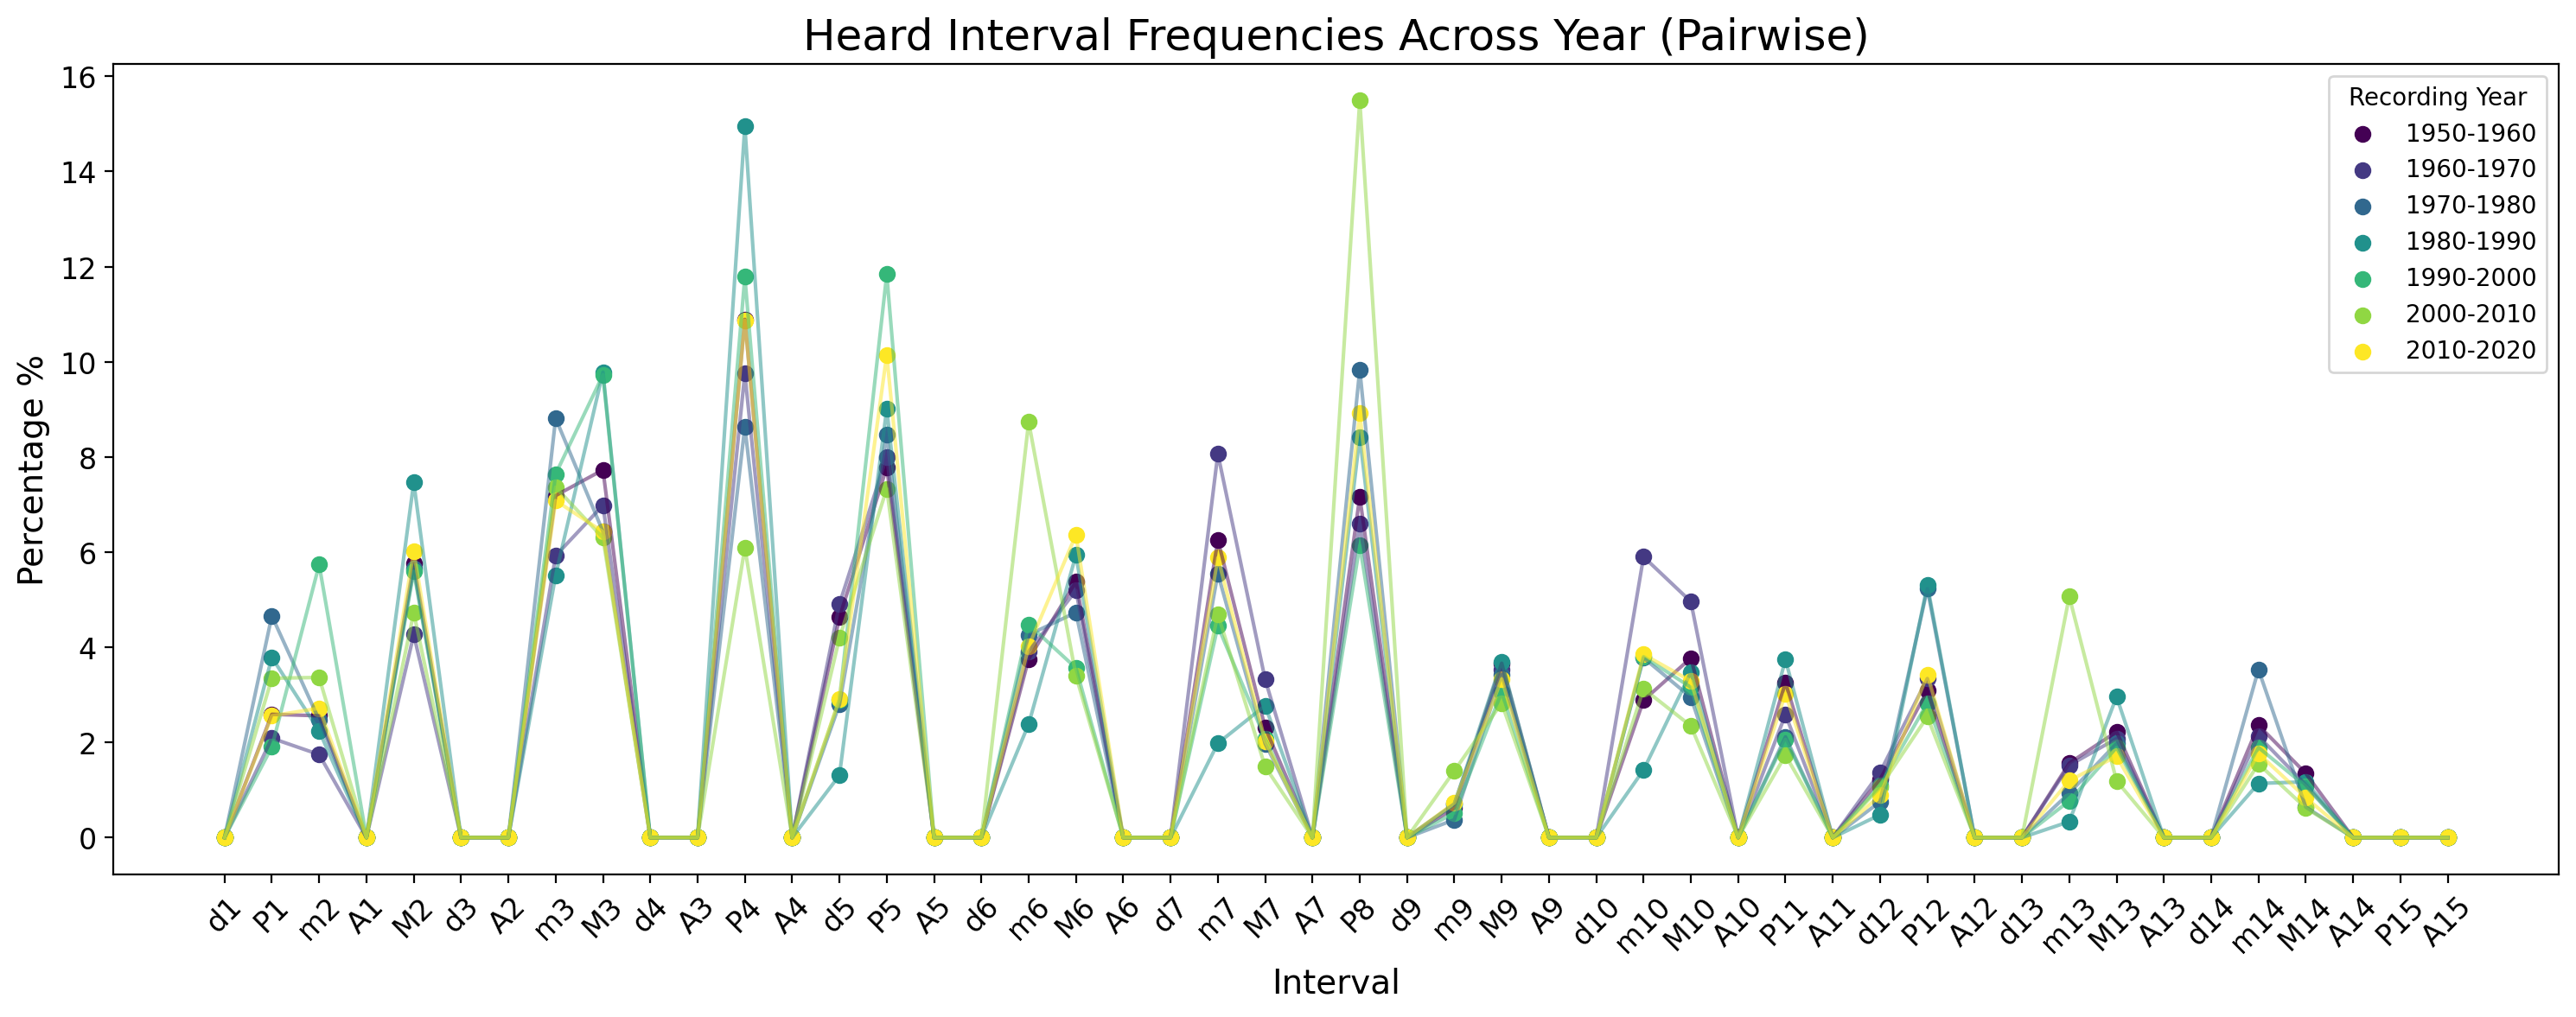

In [117]:
baseline_df = pd.DataFrame({
    'interval_name': ia.canonical_intervals,
    'percentage': 0.0
})

keys = list(data_heard_year.keys())

fig, ax = plt.subplots(figsize=(15, 6))  

colors = plt.colormaps['viridis']

for i, key in enumerate(keys):

    interval = data_heard_year[key]
    interval = pd.DataFrame({'interval_name': interval['interval'], 'duration': interval['duration_qb']})
    interval = interval.explode('interval_name')

    interval_counts = (
        interval.groupby(['interval_name'])['duration']
        .sum()
        .reset_index(name='weighted_count')
    )

    #interval_counts['semitone'] = interval_counts['interval_name'].apply(lambda x: m21.interval.Interval(x).semitones)
    interval_counts['semitone'] = interval_counts['interval_name'].map(ia.interval_order)
    count = interval_counts.sort_values('semitone', ascending=True)
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    merged_df = pd.merge(
        baseline_df[['interval_name']],
        count[['interval_name', 'percentage']],
        on='interval_name',
        how='left'
    )
    
    #fill NaNs with 0 where artist didn't have that interval
    merged_df['percentage'] = merged_df['percentage'].fillna(0)
    
    merged_df = merged_df[['interval_name', 'percentage']]
    
    # Plot bar chart
    ax.plot(merged_df['interval_name'], merged_df['percentage'], color=colors(i / (len(keys) - 1)), alpha=0.5)
    ax.scatter(merged_df['interval_name'], merged_df['percentage'], label=label, color=colors(i / (len(keys) - 1)))

ax.tick_params(axis='x', labelsize=12, rotation=45)
ax.tick_params(axis='y', labelsize=12)
ax.set_xlabel('Interval', fontsize=14)
ax.set_ylabel('Percentage %', fontsize=14)
ax.set_title(f'Heard Interval Frequencies Across Year (Pairwise)', fontsize=18)
ax.legend(title='Recording Year')

plt.tight_layout()
plt.savefig(f"../Results/Year_Interval_Heard_Cut")
plt.show()


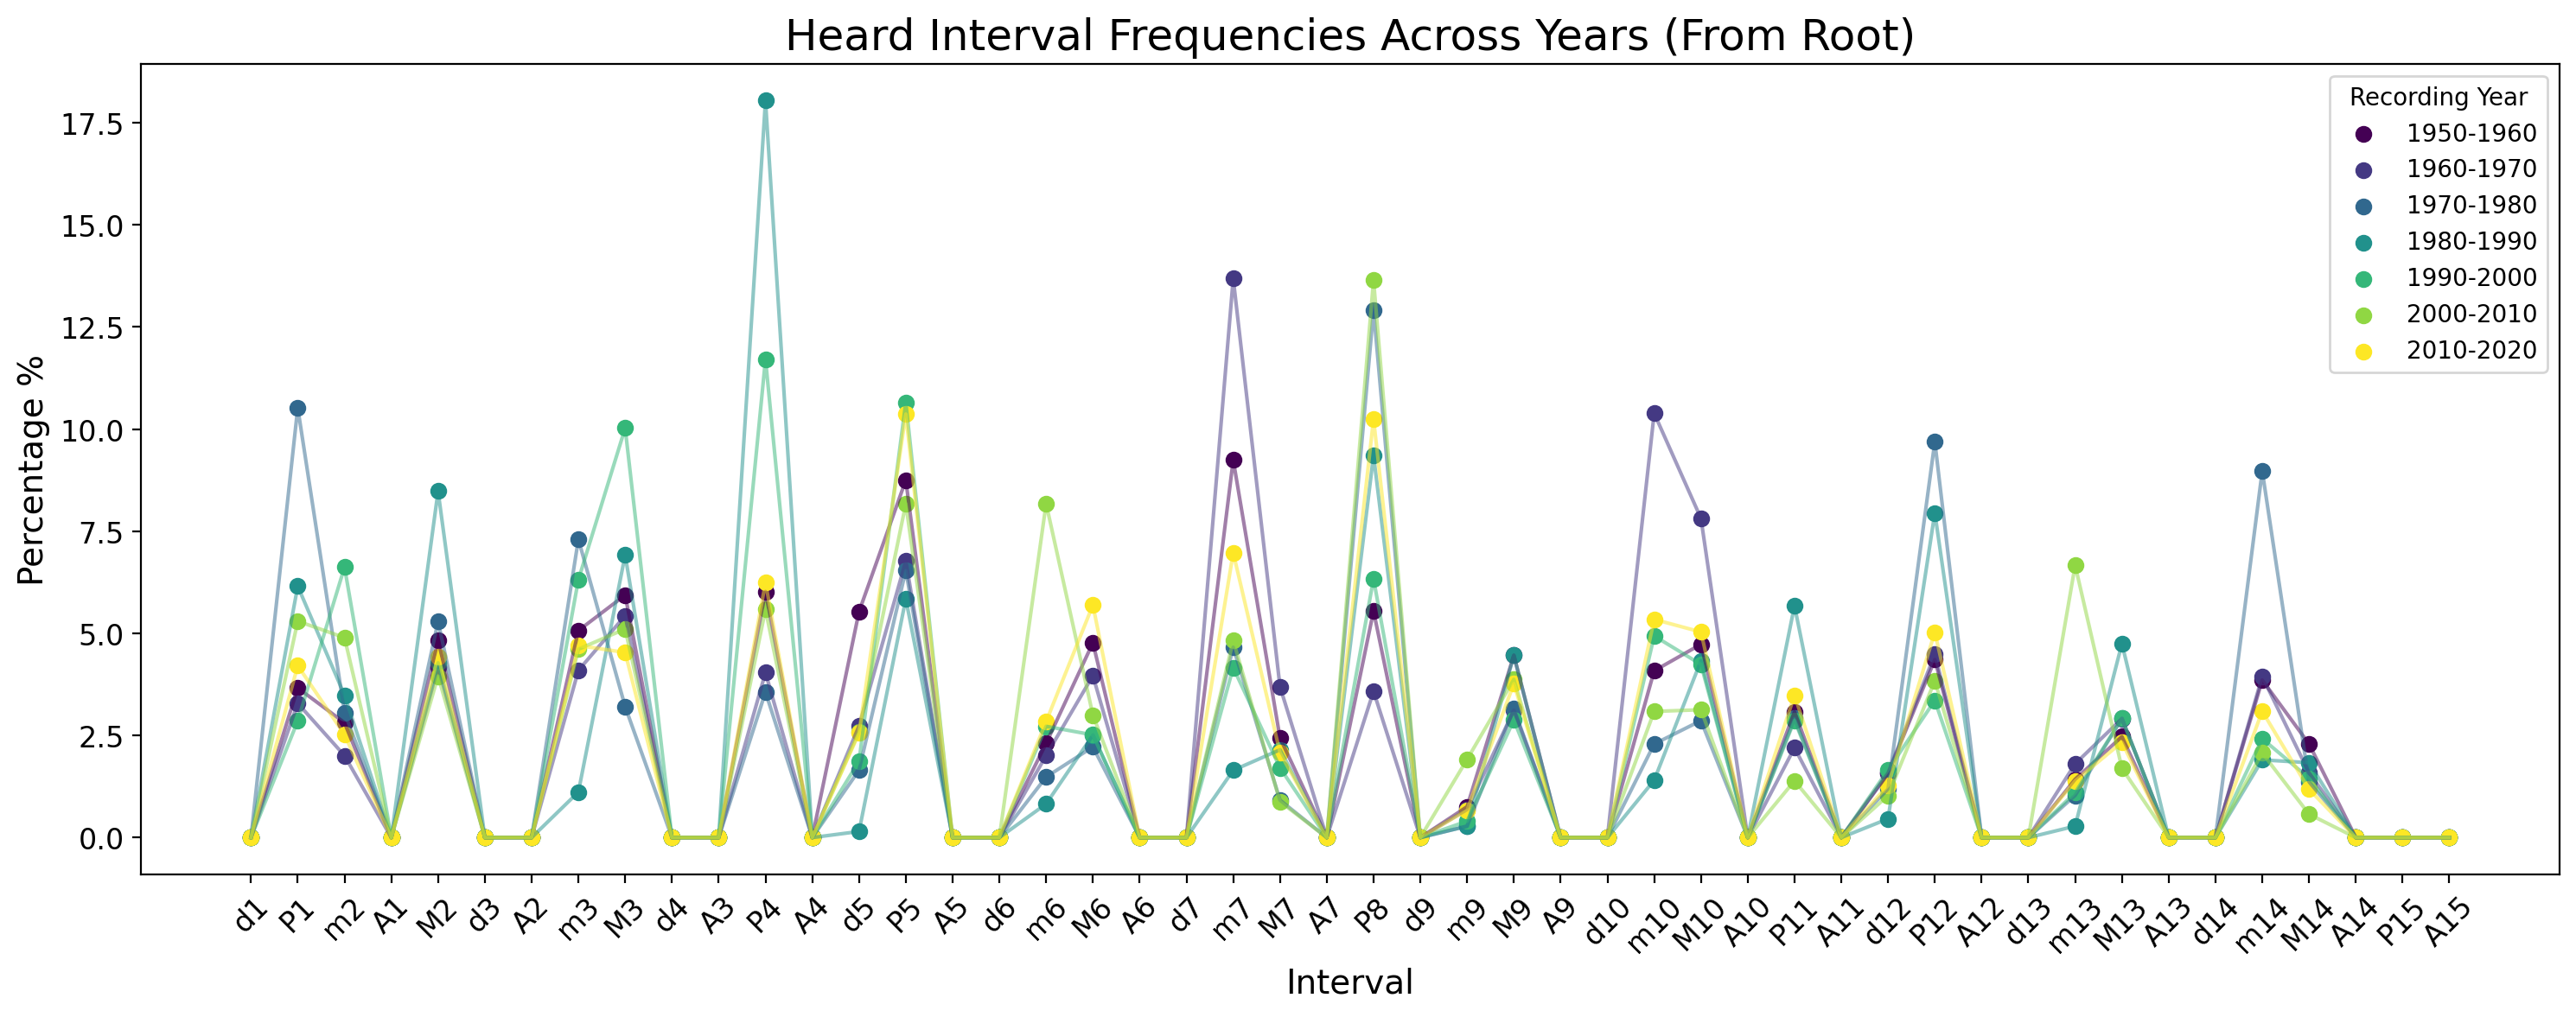

In [118]:
baseline_df = pd.DataFrame({
    'interval_name': ia.canonical_intervals,
    'percentage': 0.0
})

keys = list(data_heard_year.keys())

fig, ax = plt.subplots(figsize=(15, 6))  

colors = plt.colormaps['viridis']

for i, key in enumerate(keys):

    interval = data_heard_year[key]
    interval = pd.DataFrame({'interval_name': interval['interval from root'], 'duration': interval['duration_qb']})
    interval = interval.explode('interval_name')

    interval_counts = (
        interval.groupby(['interval_name'])['duration']
        .sum()
        .reset_index(name='weighted_count')
    )

    #interval_counts['semitone'] = interval_counts['interval_name'].apply(lambda x: m21.interval.Interval(x).semitones)
    interval_counts['semitone'] = interval_counts['interval_name'].map(ia.interval_order)
    count = interval_counts.sort_values('semitone', ascending=True)
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    merged_df = pd.merge(
        baseline_df[['interval_name']],
        count[['interval_name', 'percentage']],
        on='interval_name',
        how='left'
    )
    
    #fill NaNs with 0 where artist didn't have that interval
    merged_df['percentage'] = merged_df['percentage'].fillna(0)
    
    merged_df = merged_df[['interval_name', 'percentage']]
    
    # Plot bar chart
    ax.plot(merged_df['interval_name'], merged_df['percentage'], color=colors(i / (len(keys) - 1)), alpha=0.5)
    ax.scatter(merged_df['interval_name'], merged_df['percentage'], label=label, color=colors(i / (len(keys) - 1)))

ax.tick_params(axis='x', labelsize=12, rotation=45)
ax.tick_params(axis='y', labelsize=12)
ax.set_xlabel('Interval', fontsize=14)
ax.set_ylabel('Percentage %', fontsize=14)
ax.set_title(f'Heard Interval Frequencies Across Years (From Root)', fontsize=18)
ax.legend(title='Recording Year')

plt.tight_layout()
plt.savefig(f"../Results/Year_Interval_Heard_From_Root")
plt.show()